In [ ]:
import matplotlib.pyplot as plt
import numpy as np

## Example Calculations
This notebook will briefly introduce the usage of the *PyWVLTConCoeff* package. The math formalism accompaning the code snippets follows our paper.

### 1. Low-Memory vs. Vectorized solvers

First, we briefly want to explain the difference in our two implementations on the example of the two-term connection coefficient. The two-term connection coefficients are defined as
$$
    \Gamma^{(i)}_k = \int \phi(t)\frac{\partial^i \phi(t-k)}{\partial t^i}dt
$$
where $(i)$ denotes the order of differentitation. The *PyWVLTConCoeff* package includes two functions for calculating the connection coefficients.

In [ ]:
from wvltcc.coeffs import two_term_coeff_solver, two_term_coeff_solver_low_mem

A low-memory implementation and a vectorized implementation. The main difference in these implementations currently lies in the population of the matrix $\mathbf{H}$ with the filter coefficients for the overdetermined linear system. In the two-term case, $\mathbf{H}$ is defined as
$$
    H_{r,c} = \sum_{n_0=0}^{N-1}\sum_{n_1=0}^{N-1} h[n_0]h[n_1] \delta_{c_1, 2r_1+n_1-n_0}
$$
where $h$ are the wavelet's reconstruction filter coefficients. Further explanations on the form of $\mathbf{H}$ can be found in our paper. In the low-memory implementation, $\sum_{n_0=0}^{N-1}\sum_{n_1=0}^{N-1} h[n_0]h[n_1]$ is only calculated if $\delta_{c_1, 2r_1+n_1-n_0}=1$. Naturally, this reads as code: 

In [2]:
import pywt

filt = np.asarray(pywt.Wavelet("db3").filter_bank[2])
filt_len = len(filt)
H_len = 2 * filt_len - 3
H_mat = np.zeros((H_len, H_len))

for i in range(H_len**2):
    r = i // H_len
    c = i % H_len
    k_in = c - filt_len + 2
    k_out = r - filt_len + 2
    for n0 in range(filt_len):
        for n1 in range(filt_len):
            if (n0 - n1) == (k_in - 2 * k_out):
                H_mat[r, c] += filt[n0] * filt[n1]

As you can see, this results in a few nested `for`-loops. Python as a high-level language is not necessary known for fast `for`-loop execution. However, this can be rewritten as elemntwise array operations, using *NumPy*'s intrinsic optimizations. Therefore, our default implementation in the `two_term_coeff_solver` function is:

In [4]:
import pywt

filt = np.asarray(pywt.Wavelet("db3").filter_bank[2])
filt_len = len(filt)
filt_idx = np.arange(-filt_len + 2, filt_len - 1)
H_len = 2 * filt_len - 3
H_mat = np.zeros((H_len, H_len))

# define flattening mapping function
def map_indices(j):
    idx = j + filt_len - 2
    return idx

# create shift luts
n = np.arange(filt_len)
n0, n1 = np.meshgrid(n, n, indexing="ij")
n0, n1 = n0.ravel(), n1.ravel()

# calculate filter products for all combinations
filt_prod = filt[n0] * filt[n1]

# create filter index luts
k1_out = filt_idx

# create k_in luts
k1_in = np.add(2 * k1_out[:, None], n1 - n0)

# mask for overlap indices
limit = filt_len - 1
mask = np.abs(k1_in) < limit

# get row and column indices of H matrix
r = map_indices(k1_out[:, None])
c = map_indices(k1_in)

# apply mask and flatten to index list
r_map = np.broadcast_to(r, c.shape)[mask]
c_map = c[mask]
filt_map = np.broadcast_to(filt_prod, c.shape)[mask]

# populate refinement matrix (np.add.at for handling repeated indices)
np.add.at(H_mat, (r_map, c_map), filt_map)

While this leads to an increased amount of operations, due to including all zero entries in the $\mathbf{H}$ matrix, the low-level optimization in *NumPy* and its parallel processing increases the execution by far. In the two-term case, this is in reality barely noticeable, but when we compare execution time for two-, three-, and four-term connection coefficient computation, we get

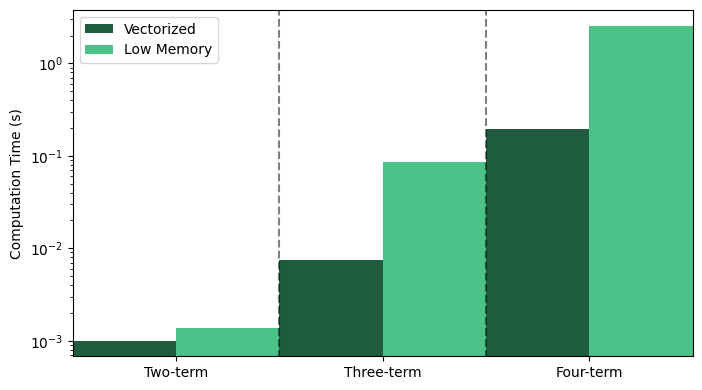

In [14]:
import wvltcc
import time

wvlt = 'db3'
dt2s = []
dt3s = []
dt4s = []

# two-term solver timings
t0 = time.time()
tmp1 = wvltcc.coeffs.two_term_coeff_solver(wvlt, deriv_order=1, residuals=False)
t1 = time.time()
dt2s.append(t1 - t0)
t0 = time.time()
tmp2 = wvltcc.coeffs.two_term_coeff_solver_low_mem(wvlt, deriv_order=1, residuals=False)
t1 = time.time()
dt2s.append(t1 - t0)

# three-term solver timings
t0 = time.time()
tmp11 = wvltcc.coeffs.three_term_coeff_solver(wvlt, deriv_orders=np.array([1, 1]), residuals=False)
t1 = time.time()
dt3s.append(t1 - t0)
t0 = time.time()
tmp22 = wvltcc.coeffs.three_term_coeff_solver_low_mem(wvlt, deriv_orders=np.array([1, 1]), residuals=False)
t1 = time.time()
dt3s.append(t1 - t0)

# four-term solver timings
t0 = time.time()
tmp111 = wvltcc.coeffs.four_term_coeff_solver(wvlt, deriv_orders=np.array([1, 1, 1]), residuals=False)
t1 = time.time()
dt4s.append(t1 - t0)
t0 = time.time()
tmp222 = wvltcc.coeffs.four_term_coeff_solver_low_mem(wvlt, deriv_orders=np.array([1, 1, 1]), residuals=False)
t1 = time.time()
dt4s.append(t1 - t0)

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.bar(np.array([0, 2, 4]), np.array([dt2s[0], dt3s[0], dt4s[0]]), width=1, color='#1f5b3e', label='Vectorized')
ax.bar(np.array([1, 3, 5]), np.array([dt2s[1], dt3s[1], dt4s[1]]), width=1, color='#4bc288', label='Low Memory')
ax.set_xticks([0.5, 2.5, 4.5])
ax.set_xlim(-0.5, 5.5)
ax.set_yscale('log')
ax.vlines([1.5, 3.5], ymin=1e-4, ymax=1e2, colors='k', linestyles='dashed', alpha=0.5)
ax.set_xticklabels(['Two-term', 'Three-term', 'Four-term'])
ax.set_ylabel('Computation Time (s)')
ax.legend()

### 2. Computing Connection Coefficients

Here, we briefly show the usage of the solver functions for the two-term
$$
    \Gamma^{(i)}_k = \int \phi(t)\frac{\partial^i \phi(t-k)}{\partial t^i}dt
$$
three-term
$$
    \Omega^{(i_1),(i_2)}_{k_1, k_2} = \int \phi(t)\frac{\partial^{i_1} \phi(t-k_1)}{\partial t^{i_1}}\frac{\partial^{i_2} \phi(t-k_2)}{\partial t^{i_2}}dt
$$
and four-term connection coefficient computation
$$
    \Lambda^{(i_1),(i_2),(i_3)}_{k_1, k_2, k_3} = \int \phi(t)\frac{\partial^{i_1} \phi(t-k_1)}{\partial t^{i_1}}\frac{\partial^{i_2} \phi(t-k_2)}{\partial t^{i_2}}\frac{\partial^{i_3} \phi(t-k_3)}{\partial t^{i_3}}dt
$$

First, the two-term function is used as follows:

In [ ]:
from wvltcc.coeffs import two_term_coeff_solver, two_term_coeff_solver_low_mem

wvlt = 'db3'
i = 1

two_term = two_term_coeff_solver(wvlt, i)
two_term_low_mem = two_term_coeff_solver_low_mem(wvlt, i)

Optionally, residuals for the refinement relations and the moments constraints can be computed and returned via:

In [ ]:
two_term, ref, mom = two_term_coeff_solver(wvlt, i, residuals=True)

This works in the same way for all solver functions.

Similarily, the three-term solver function is used as:

In [ ]:
from wvltcc.coeffs import three_term_coeff_solver, three_term_coeff_solver_low_mem

wvlt = 'db3'
i1 = 1
i2 = 1

three_term = three_term_coeff_solver(wvlt, np.array([i1, i2]))
three_term_low_mem = three_term_coeff_solver_low_mem(wvlt, np.array([i1, i2]))

And the four-term one as:

In [ ]:
from wvltcc.coeffs import four_term_coeff_solver, four_term_coeff_solver_low_mem

wvlt = 'db3'
i1 = 1
i2 = 1
i3 = 1

four_term = four_term_coeff_solver(wvlt, np.array([i1, i2, i3]))
four_term_low_mem = four_term_coeff_solver_low_mem(wvlt, np.array([i1, i2, i3]))